# Loading Required Libraries

In [797]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

from sklearn.pipeline import Pipeline 

from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# Loading Project Dataset

In [760]:
data = pd.read_csv('/Users/dhruvvashishtha/Desktop/Dhruv/Projects/Big Mart Sales Prediction/train.csv')

data.head(1)

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.3,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.138


In [761]:
data.columns = data.columns.str.lower()

# Dataset Overview and Summary Statistics

Reviewing the dataset structure, data types, missing values, and key summary statistics to assess data quality, understand feature distributions, and identify potential anomalies prior to analysis

In [762]:
data.shape

(8523, 12)

In [763]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   item_identifier            8523 non-null   object 
 1   item_weight                7060 non-null   float64
 2   item_fat_content           8523 non-null   object 
 3   item_visibility            8523 non-null   float64
 4   item_type                  8523 non-null   object 
 5   item_mrp                   8523 non-null   float64
 6   outlet_identifier          8523 non-null   object 
 7   outlet_establishment_year  8523 non-null   int64  
 8   outlet_size                6113 non-null   object 
 9   outlet_location_type       8523 non-null   object 
 10  outlet_type                8523 non-null   object 
 11  item_outlet_sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [764]:
data.describe()

,item_weight,item_visibility,item_mrp,outlet_establishment_year,item_outlet_sales
count,7060.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,1997.831867,2181.288914
std,4.643456,0.051598,62.275067,8.371760,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,8.773750,0.026989,93.826500,1987.000000,834.247400
50%,12.600000,0.053931,143.012800,1999.000000,1794.331000
75%,16.850000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


The minimum value of the item_visibility feature is 0, which is not realistic because items displayed in a store should have some level of visibility. Therefore, these zero values would be treated as missing observations rather than true measurements.

To address this, all instances where item_visibility = 0 would first be first converted to null values. These missing values would then be imputed using the mean visibility for the corresponding item_identifier.

Converting zeros to null values before imputation would ensure that the mean calculation excludes the invalid zero values. If the zeros were directly replaced with the group mean without this step, the mean itself would have been calculated including the zero values, which would artificially lower the average visibility and introduce bias in the imputed values.

In [765]:
data['item_visibility'] = data['item_visibility'].replace(0, np.nan)

data['item_visibility'] = data.groupby('item_identifier')['item_visibility'].transform(lambda x: x.fillna(x.mean()))

In [766]:
data.isna().sum().sort_values(ascending = False)

outlet_size                  2410
item_weight                  1463
item_identifier                 0
item_fat_content                0
item_visibility                 0
item_type                       0
item_mrp                        0
outlet_identifier               0
outlet_establishment_year       0
outlet_location_type            0
outlet_type                     0
item_outlet_sales               0
dtype: int64

Checking the total number of missing values in each column, the dataset shows that outlet_size and item_weight are the features with ~2.4k and ~1.5k nulls respectively, while all other columns are complete

In [767]:
np.round(data.isna().mean()*100, 1).sort_values(ascending = False)

outlet_size                  28.3
item_weight                  17.2
item_identifier               0.0
item_fat_content              0.0
item_visibility               0.0
item_type                     0.0
item_mrp                      0.0
outlet_identifier             0.0
outlet_establishment_year     0.0
outlet_location_type          0.0
outlet_type                   0.0
item_outlet_sales             0.0
dtype: float64

To better understand the scale of missingness, we calculate the percentage of missing values. outlet_size and item_weight contain 28%  and 17% nulls respectively

In [768]:
data['item_weight'] = data.groupby('item_identifier')['item_weight'].transform(lambda x: x.fillna(x.mean()))

Missing values in the item_weight column are handled.

Instead of using the overall average, the data is grouped by item_identifier because the same product appears across multiple stores. Since a product’s weight remains constant regardless of the store, it makes more sense to use the average weight of that specific item. Using groupby() along with transform(), the mean weight for each product is calculated and missing values within that group are filled accordingly. This ensures the imputation is logical, consistent, and better suited for building an accurate model.

In [769]:
data['outlet_size'] = (data.groupby('outlet_identifier')['outlet_size'].transform(lambda x: x.where(x.notna(), x.mode().iloc[0] if not x.mode().empty else np.nan)))

In this step, missing values in the outlet_size column are handled.

The data is grouped by outlet_identifier because each outlet has a fixed size (such as Small, Medium, or High). Since the outlet size does not change for the same outlet, it makes sense to fill missing values based on the most frequent size recorded for that outlet. Using groupby() and transform(), the mode (most common value) of outlet_size is calculated within each outlet group. Any missing values are then replaced with that mode. If no mode is available, the value remains missing.

This approach keeps the imputation consistent at the outlet level and maintains logical accuracy in the dataset.

In [770]:
data.isna().sum().sort_values(ascending = False)

outlet_size                  2410
item_weight                     4
item_identifier                 0
item_fat_content                0
item_visibility                 0
item_type                       0
item_mrp                        0
outlet_identifier               0
outlet_establishment_year       0
outlet_location_type            0
outlet_type                     0
item_outlet_sales               0
dtype: int64

In [771]:
data['item_weight'] = data['item_weight'].fillna(data['item_weight'].median())

After handling missing values in item_weight and outlet_size, the dataset is checked again to see if any missing values still remain.

The isna() function identifies missing entries, sum() counts them for each column, and the results are sorted in descending order to quickly spot columns with the highest missing values.

The output shows that missing values are still present, especially in outlet_size. This indicates that the previous imputation did not completely resolve all missing entries, likely because some outlet groups did not have enough information.

In [772]:
data['outlet_size'] = (data.groupby(['outlet_type', 'outlet_location_type'])['outlet_size'].transform(lambda x: x.where(x.notna(), x.mode().iloc[0] if not x.mode().empty else np.nan)))

Since missing values were still present in outlet_size, a more detailed grouping approach is applied.

Instead of grouping only by outlet_identifier, the data is now grouped by both outlet_type and outlet_location_type. This assumes that outlets with similar type and location characteristics are likely to have similar sizes.

Within each group, the mode (most frequent value) of outlet_size is calculated. Any missing values in that group are replaced with this mode. If a group does not have a valid mode, the value remains missing.

This approach provides a more generalized and logically consistent way to fill missing values when outlet-level information alone is not sufficient.

In [773]:
data.isna().sum().sort_values(ascending = False)

outlet_size                  555
item_identifier                0
item_weight                    0
item_fat_content               0
item_visibility                0
item_type                      0
item_mrp                       0
outlet_identifier              0
outlet_establishment_year      0
outlet_location_type           0
outlet_type                    0
item_outlet_sales              0
dtype: int64

After applying the refined grouping strategy, missing values are checked again across all columns.

The output shows that most columns no longer contain any missing values. However, outlet_size still has some remaining missing entries.

This indicates that even with grouping by outlet_type and outlet_location_type, certain combinations still did not have enough information (such as a valid mode) to fill all missing values.

At this stage, only a small portion of the dataset remains incomplete, and a final imputation strategy may be required to fully clean the data.

In [774]:
data['outlet_size'] = data['outlet_size'].fillna(data['outlet_size'].mode()[0])

Since a small number of missing values still remained in outlet_size, a final imputation step is applied.

The remaining missing entries are filled using the overall mode (most frequent value) of the outlet_size column. This ensures that no missing values are left in the dataset.

Using the mode is appropriate here because outlet_size is a categorical variable. Filling with the most common category maintains consistency without introducing unrealistic values.

After this step, the dataset becomes fully complete and ready for further analysis or model building.

In [775]:
data.isna().sum().sort_values(ascending = False)

item_identifier              0
item_weight                  0
item_fat_content             0
item_visibility              0
item_type                    0
item_mrp                     0
outlet_identifier            0
outlet_establishment_year    0
outlet_size                  0
outlet_location_type         0
outlet_type                  0
item_outlet_sales            0
dtype: int64

After applying all imputation steps, the dataset is checked once again for missing values.

The output shows that all columns now have zero missing values. This confirms that the data cleaning process has been successfully completed.

With no missing entries remaining, the dataset is now fully prepared for further exploratory analysis and model building.

# Visualizing Dataset Features

Text(0.5, 1.0, 'Distribution of Item Weight')

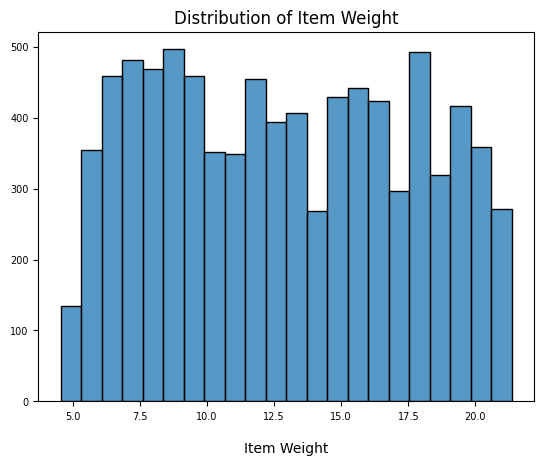

In [776]:
ax = sns.histplot(data['item_weight'])

ax.tick_params(labelsize = 7)
ax.set_xlabel('Item Weight', labelpad = 15)
ax.set_ylabel('')
ax.set_title('Distribution of Item Weight')

The distribution of item weight appears fairly spread out across the range, without any extreme spikes or heavy skewness. Most items are distributed relatively evenly between lower and higher weight ranges.

There are no obvious outliers or unusual concentrations in a specific weight category, suggesting that the feature is well-balanced.

Overall, item_weight seems to have a stable distribution, which is helpful for modeling since it does not show problematic skewness or irregular patterns.

Text(0.5, 1.0, 'Distribution of Item Fat Content')

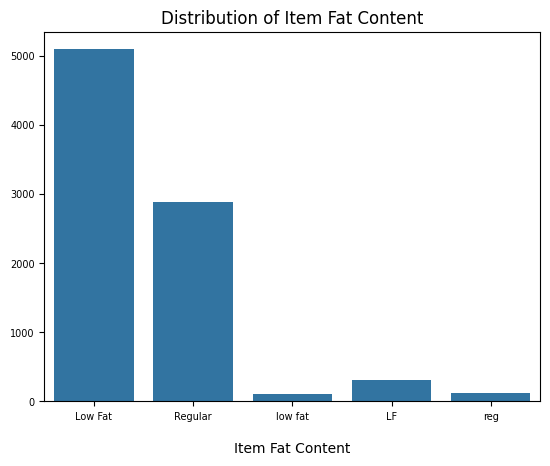

In [777]:
ax = sns.countplot(data, x = 'item_fat_content')

ax.tick_params(labelsize = 7)
ax.set_xlabel('Item Fat Content', labelpad = 15)
ax.set_ylabel('')
ax.set_title('Distribution of Item Fat Content')

The majority of items fall under the Low Fat category, followed by Regular. This indicates that low-fat products are more commonly available or stocked in the dataset.

There are also additional categories such as low fat, LF, and reg, which appear to represent the same meanings as the main categories but are written differently. This suggests inconsistency in categorical labeling.

Overall, the feature is dominated by two main categories, but it requires cleaning to standardize duplicate labels before modeling.

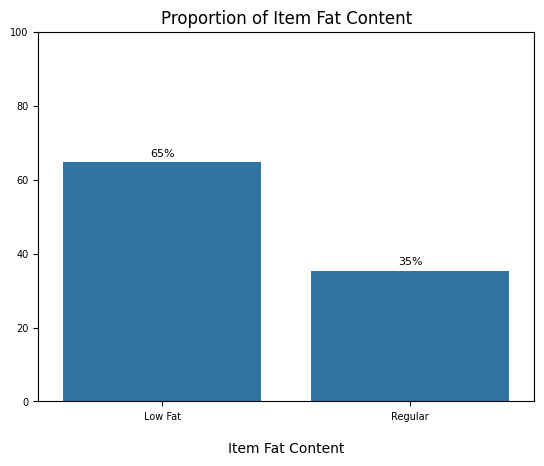

In [778]:
data['item_fat_content'] = data['item_fat_content'].replace({'low fat': 'Low Fat', 'LF': 'Low Fat', 'reg': 'Regular'})

ax = sns.countplot(data, x = 'item_fat_content', stat = 'percent')

ax.tick_params(labelsize = 7)
ax.set_xlabel('Item Fat Content', labelpad = 15)
ax.set_ylabel('')
ax.set_title('Proportion of Item Fat Content')
ax.set_ylim(0, 100)

for container in ax.containers:
    labels = [f'{int(round(bar.get_height()))}%' for bar in container]
    ax.bar_label(container, labels=labels, padding=3, fontsize=8)

After standardizing the category labels, the distribution becomes clearer and more meaningful.

Approximately 65% of the products are categorized as Low Fat, while around 35% fall under Regular. This shows that low-fat products dominate the inventory in the dataset.

The imbalance suggests that healthier or low-fat options are more commonly stocked. From a modeling perspective, this feature is now clean and well-structured, with only two clear categories and no duplication issues.

Text(0.5, 1.0, 'Distribution of Item Visibility')

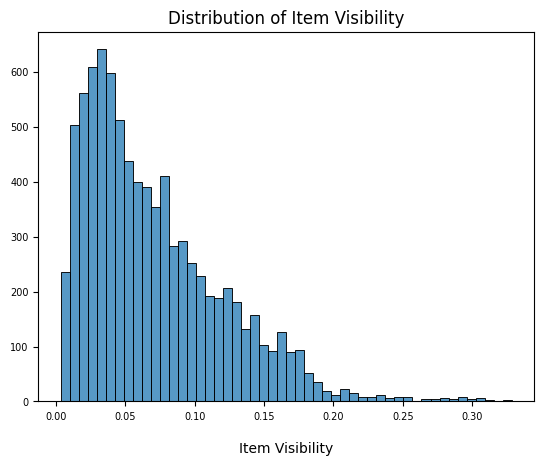

In [779]:
ax = sns.histplot(data['item_visibility'])

ax.tick_params(labelsize = 7)
ax.set_xlabel('Item Visibility', labelpad = 15)
ax.set_ylabel('')
ax.set_title('Distribution of Item Visibility')

The distribution of item_visibility is highly right-skewed. Most items have low visibility values, while only a small number of items have very high visibility.

There is a strong concentration of observations near the lower end of the scale, suggesting that most products are placed in less prominent positions within stores.

A few extreme values appear on the higher end, which may indicate outliers or special promotional placements. This skewness may require transformation or further investigation before modeling.

Text(0.5, 1.0, 'Distribution of Log Item Visibility')

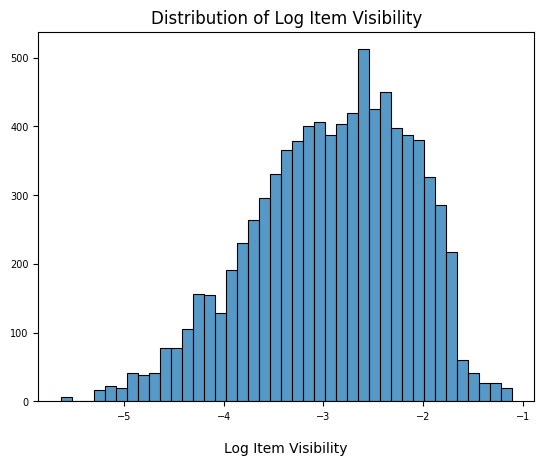

In [780]:
data['item_visibility_log'] = np.log(data['item_visibility'] + 1e-6)

ax = sns.histplot(data['item_visibility_log'])

ax.tick_params(labelsize = 7)
ax.set_xlabel('Log Item Visibility', labelpad = 15)
ax.set_ylabel('')
ax.set_title('Distribution of Log Item Visibility')

To reduce skewness and make the distribution more suitable for modeling, a log transformation is applied to the variable. A small constant is added before applying the logarithm to avoid issues with zero values. The resulting distribution of the log-transformed variable is shown above.

After applying the log transformation, the distribution of item visibility becomes much more symmetric and closer to a normal distribution.

The extreme right skew observed earlier is significantly reduced, and the values are now more evenly spread around the center. This makes the feature more stable and suitable for modeling, especially for algorithms that perform better with normally distributed inputs.

Overall, the transformation helps reduce the impact of extreme values and improves the overall structure of the feature.

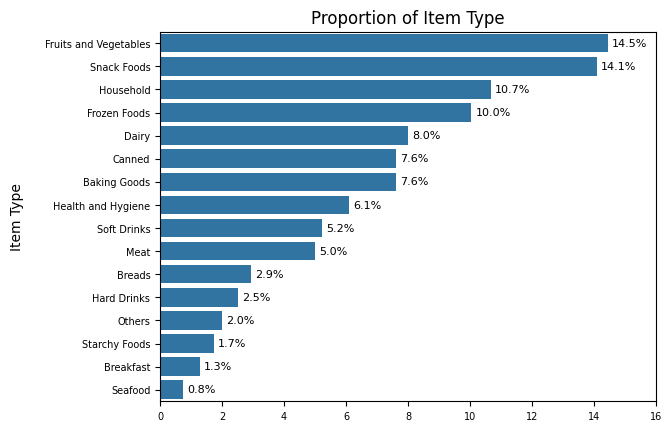

In [781]:
ax = sns.countplot(data, y = 'item_type', order = data['item_type'].value_counts().index, stat = 'percent')

ax.tick_params(labelsize = 7)
ax.set_ylabel('Item Type', labelpad = 15)
ax.set_xlabel('')
ax.set_title('Proportion of Item Type')
ax.set_xlim(0, 16)

for container in ax.containers:
    labels = [f'{np.round(bar.get_width(), 1)}%' for bar in container]
    ax.bar_label(container, labels=labels, padding=3, fontsize=8)

The dataset contains a diverse range of product categories, with Fruits and Vegetables and Snack Foods being the most common, each contributing around 14–15% of the total items.

Categories such as Household, Frozen Foods, and Dairy also make up a significant portion of the inventory, indicating that essential and frequently purchased goods dominate the dataset.

On the other hand, categories like Seafood, Breakfast, and Starchy Foods represent a very small percentage, suggesting limited availability or lower stocking frequency.

Overall, the distribution shows a clear imbalance across product categories, which may influence sales patterns and should be considered during modeling.

Text(0.5, 1.0, 'Distribution of Item MRP')

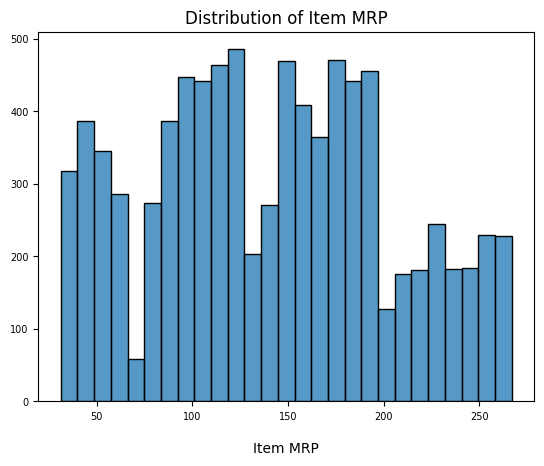

In [782]:
ax = sns.histplot(data['item_mrp'])

ax.tick_params(labelsize = 7)
ax.set_xlabel('Item MRP', labelpad = 15)
ax.set_ylabel('')
ax.set_title('Distribution of Item MRP')

The distribution of item_mrp shows a wide spread of prices across products. The values appear to form multiple peaks rather than a single smooth distribution, suggesting possible pricing tiers or product segments.

There is no extreme skewness, but the presence of clusters indicates that products may be grouped into low, medium, and high price ranges.

Overall, the feature shows strong variability, which could play a significant role in predicting sales since pricing often directly influences customer demand.

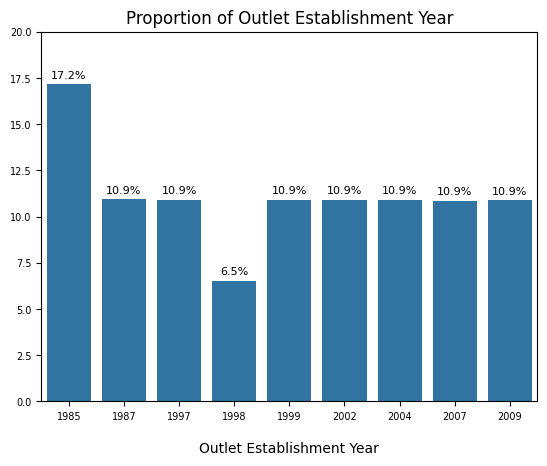

In [783]:
ax = sns.countplot(data, x = 'outlet_establishment_year', stat = 'percent')

ax.tick_params(labelsize = 7)
ax.set_xlabel('Outlet Establishment Year', labelpad = 15)
ax.set_ylabel('')
ax.set_title('Proportion of Outlet Establishment Year')
ax.set_ylim(0, 20)

for container in ax.containers:
    labels = [f'{np.round(bar.get_height(), 1)}%' for bar in container]
    ax.bar_label(container, labels=labels, padding=3, fontsize=8)

The outlets in the dataset were established across multiple years, ranging from the mid-1980s to 2009.

The year 1985 has the highest proportion of outlets, indicating that some of the oldest outlets contribute significantly to the dataset. Most other years show a fairly similar proportion, suggesting a relatively balanced distribution of outlets established over time.

The year 1998 has a comparatively lower representation, making it the least common establishment year.

Overall, the data includes a mix of older and newer outlets, which may allow analysis of how outlet age influences sales performanc

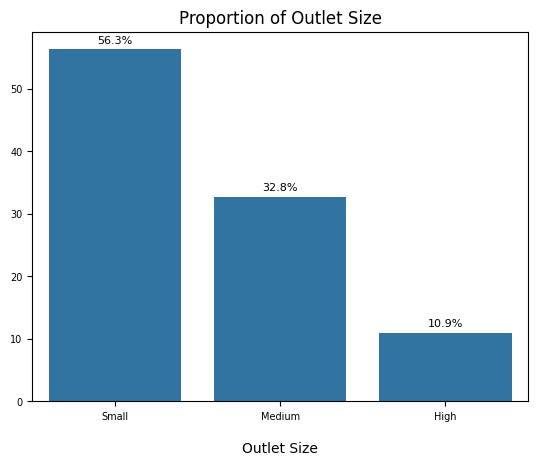

In [784]:
ax = sns.countplot(data, x = 'outlet_size', stat = 'percent', order = data['outlet_size'].value_counts().index)

ax.tick_params(labelsize = 7)
ax.set_xlabel('Outlet Size', labelpad = 15)
ax.set_ylabel('')
ax.set_title('Proportion of Outlet Size')

for container in ax.containers:
    labels = [f'{float(np.round(bar.get_height(), 1))}%' for bar in container]
    ax.bar_label(container, labels=labels, padding=3, fontsize=8)

The majority of outlets in the dataset are Small-sized, accounting for more than half of the total outlets. Medium-sized outlets form the second largest group, while High-sized outlets represent a much smaller proportion.

This indicates that the dataset is heavily skewed toward smaller stores. As a result, sales patterns may be more influenced by small outlet behavior compared to large ones.

The imbalance in outlet sizes could also impact modeling, as the representation of large outlets is relatively limited.

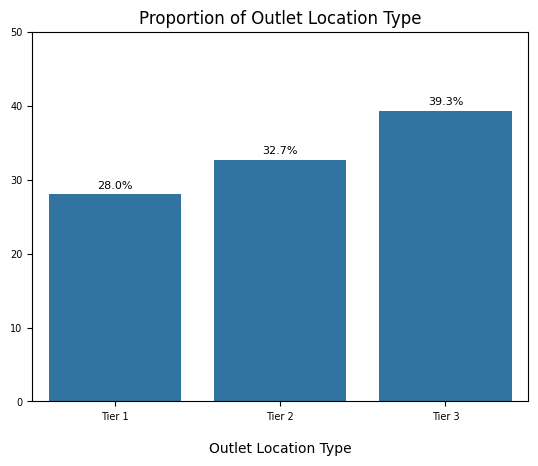

In [785]:
ax = sns.countplot(data, x = 'outlet_location_type', stat = 'percent', order = data['outlet_location_type'].value_counts(ascending = True).index)

ax.tick_params(labelsize = 7)
ax.set_xlabel('Outlet Location Type', labelpad = 15)
ax.set_ylabel('')
ax.set_title('Proportion of Outlet Location Type')
ax.set_ylim(0, 50)

for container in ax.containers:
    labels = [f'{float(np.round(bar.get_height(), 1))}%' for bar in container]
    ax.bar_label(container, labels=labels, padding=3, fontsize=8)

The dataset includes outlets across three location tiers. Tier 3 locations have the highest representation, followed by Tier 2, while Tier 1 has the lowest proportion.

This suggests that a larger portion of the data comes from outlets located in smaller cities or semi-urban areas (typically associated with Tier 3).

The distribution is relatively balanced, but Tier 3 outlets dominate slightly, which may influence overall sales trends and customer behavior patterns in the dataset.

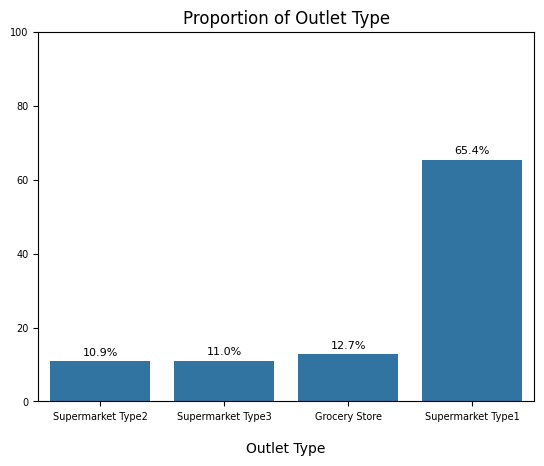

In [786]:
ax = sns.countplot(data, x = 'outlet_type', stat = 'percent', order = data['outlet_type'].value_counts(ascending = True).index)

ax.tick_params(labelsize = 7)
ax.set_xlabel('Outlet Type', labelpad = 15)
ax.set_ylabel('')
ax.set_title('Proportion of Outlet Type')
ax.set_ylim(0, 100)

for container in ax.containers:
    labels = [f'{float(np.round(bar.get_height(), 1))}%' for bar in container]
    ax.bar_label(container, labels=labels, padding=3, fontsize=8)

The dataset is heavily dominated by Supermarket Type1, which accounts for more than 65% of the outlets. This makes it the primary outlet format represented in the data.

The remaining outlet types — Grocery Store, Supermarket Type2, and Supermarket Type3 — each contribute a much smaller and relatively similar proportion.

This strong imbalance suggests that overall sales trends may be largely influenced by Supermarket Type1 outlets. The limited representation of other outlet types should be considered during modeling, as patterns from smaller groups may have less impact on predictions.

# Modeling

## Train - Test - Validation Split

In [787]:
X = data.drop(columns = 'item_outlet_sales')
y = data['item_outlet_sales']

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size = 0.3, random_state = 12)

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size = 0.5, random_state = 12)

The dataset is divided into features and target, where item_outlet_sales is treated as the prediction variable and all other columns are used as input features.

The data is then split into three parts: training, validation, and testing sets.
	•	70% of the data is used for training.
	•	The remaining 30% is split equally into validation and test sets (15% each).

This structured split allows the model to be trained on one portion of the data, tuned on the validation set, and finally evaluated on completely unseen test data. Using separate validation and test sets helps ensure more reliable and unbiased performance evaluation.

## Feature Engineering

In [ ]:
stats = {}

stats['outlet_avg_map'] = y_train.groupby(X_train['outlet_identifier']).mean()

stats['outlet_item_avg_map'] = y_train.groupby([X_train['outlet_identifier'], X_train['item_type']]).mean()

stats['visibility_avg_map'] = X_train.groupby('item_identifier')['item_visibility'].mean()

stats['mrp_bins'] = pd.qcut(X_train['item_mrp'], 4, retbins=True)[1]


def feature_engineer(df, stats):

    df = df.copy()

    df['outlet_average_sales'] = df['outlet_identifier'].map(stats['outlet_avg_map'])

    df['outlet_item_type_average'] = (df.set_index(['outlet_identifier', 'item_type']).index.map(stats['outlet_item_avg_map']))

    df['visibility_ratio'] = (df['item_visibility'] / df['item_identifier'].map(stats['visibility_avg_map'])).replace([np.inf, -np.inf], np.nan).fillna(0)

    df['mrp_bins'] = pd.cut(df['item_mrp'], bins = stats['mrp_bins'], labels = ['Low', 'Medium', 'High', 'Premium'], include_lowest = True)

    df['item_category'] = df['item_identifier'].str[:2]

    df['item_fat_content'] = np.where(df['item_category'] == 'NC', 'Non Edible', df['item_fat_content'])

    df['price_per_weight'] = (df['item_mrp'] / df['item_weight']).replace([np.inf, -np.inf], np.nan).fillna(0)

    return df

This step creates additional features that help the model capture patterns in the data more effectively.

First, several summary statistics are calculated from the training data and stored in a dictionary. These statistics act as reference values that will later be used to generate new features. For example, the average sales for each outlet are calculated, along with the average sales for each combination of outlet and item type. The average visibility of each item across all outlets is also computed. In addition, the distribution of item prices is divided into four groups using quantiles, which will later be used to categorize items into price segments.

A feature engineering function is then defined to apply these transformations consistently to any dataset.

The function begins by creating a copy of the input data so that the original dataset remains unchanged. It then generates several new features using the statistics calculated earlier.

The first new feature represents the historical average sales for each outlet. This provides the model with information about how well a particular outlet generally performs.

Another feature captures the average sales for a specific combination of outlet and item type. This helps the model understand how certain product categories perform in different outlets.

The visibility ratio is then calculated by comparing an item’s visibility in a specific outlet to its overall average visibility. This helps identify whether a product is receiving more or less shelf exposure than usual.

Next, the item price is converted into categorical price segments using the previously calculated bins. This groups products into price ranges such as low, medium, high, and premium.

A simplified product category is also extracted from the item identifier by taking its first two characters. This allows the model to distinguish between broad product groups.

For non-consumable products, the fat content attribute is adjusted so that these items are labeled as “Non Edible,” ensuring that the feature remains logically consistent.

Finally, a price-per-weight feature is created by dividing the item price by its weight. This provides an estimate of how expensive a product is relative to its size.

Together, these engineered features help the model capture store performance, product characteristics, pricing structure, and product visibility patterns, all of which can influence sales.

In [789]:
def encode_and_clean(df, drop_original_visibility=True):
    
    df = df.copy()

    df.drop(columns=['item_identifier', 'outlet_identifier'], inplace=True)

    if drop_original_visibility and 'item_visibility_log' in df.columns: df.drop(columns=['item_visibility'], inplace=True)

    categorical_cols = ['item_type', 'outlet_size', 'outlet_location_type', 'outlet_type', 'item_fat_content', 'mrp_bins', 'item_category']
    
    df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
    
    return df

This step prepares the dataset for modeling by cleaning unnecessary columns and converting categorical variables into a numerical format.

The function first creates a copy of the dataset to avoid modifying the original data. Identifier columns such as the item identifier and outlet identifier are then removed, since these act only as labels and do not provide useful information for predicting sales.

The original item visibility column can also be removed because a transformed version of this variable has already been created earlier. Keeping both would introduce redundant information.

Next, several categorical columns are identified, including product attributes like item type and fat content, outlet characteristics such as outlet size, location type, and outlet type, as well as the engineered price bins and product category.

These categorical variables are converted into numerical features using one-hot encoding. This creates separate binary columns for each category so that the model can use them as input features. The first category is dropped during encoding to avoid redundant columns.

After this step, the dataset contains only numerical features and is ready to be used for training machine learning models.

In [790]:
def full_preprocess(df, stats):
    
    df = feature_engineer(df, stats)
    df = encode_and_clean(df)
    
    return df.reset_index(drop = True)

This step combines the earlier preprocessing steps into a single function so that the same transformations can be applied consistently to any dataset.

The function first applies the feature engineering process, where new features such as outlet-level averages, visibility ratios, price segments, and price-per-weight are created using the statistics calculated from the training data.

Next, the dataset is passed through the encoding and cleaning step. During this stage, unnecessary identifier columns are removed and categorical variables are converted into numerical features using one-hot encoding.

Finally, the index of the dataset is reset to ensure a clean and continuous index after all transformations. The resulting dataset contains only numerical features and is ready to be used for model training and evaluation.

In [791]:
X_train = full_preprocess(X_train, stats)
X_val = full_preprocess(X_val, stats)
X_test = full_preprocess(X_test, stats)

The preprocessing pipeline is now applied to the training, validation, and test datasets.

Each dataset is passed through the same full_preprocess function, which performs feature engineering followed by cleaning and encoding. Using the same preprocessing steps across all datasets ensures that the features are created and formatted in a consistent way.

The statistics calculated from the training data are reused during this process. This prevents information from the validation or test sets from influencing the feature creation process, helping maintain a fair and unbiased evaluation of model performance.

After this step, all three datasets contain the same set of processed numerical features and are ready for model training and evaluation.

## Model Performance Evaluation And Result Tracking

In [817]:
results = []

def create_results(name, model):

    y_pred_train = model.predict(X_train)
    y_pred_val = model.predict(X_val)

    results.append({
        'model': name,

        'rmse_train': round(np.sqrt(mean_squared_error(y_train, y_pred_train)), 2),
        'mae_train': round(mean_absolute_error(y_train, y_pred_train), 2),
        'r2_train': round(r2_score(y_train, y_pred_train), 3),

        'rmse_validation': round(np.sqrt(mean_squared_error(y_val, y_pred_val)), 2),
        'mae_validation': round(mean_absolute_error(y_val, y_pred_val), 2),
        'r2_validation': round(r2_score(y_val, y_pred_val), 3)
    })

This step creates a helper function to evaluate model performance and store the results in a structured format.

The function takes a model and its name as input, generates predictions for both the training and validation datasets, and calculates several evaluation metrics. These include Root Mean Squared Error, Mean Absolute Error, and R-squared.

The calculated metrics are then stored in a results list along with the model name. This makes it easy to compare the performance of multiple models later in a single summary table.

## Linear Regression

In [814]:
linear = LinearRegression()

linear.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [818]:
create_results('Linear Regression', linear)

A Linear Regression model is trained as a baseline model.

The model is fitted using the training data, allowing it to learn the relationship between the input features and the target variable. After training, the model’s performance is evaluated on both the training and validation datasets using the previously defined evaluation function. The results are then stored so they can be compared with other models later.

## Elastic Net - Base

In [798]:
elastic_net_base = Pipeline([("scaler", StandardScaler()), ("elasticnet", ElasticNet())])

elastic_net_base.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('elasticnet', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"alpha alpha: float, default=1.0Constant that multiplies the penalty terms. Defaults to 1.0.See the notes for the exact mathematical meaning of thisparameter. ``alpha = 0`` is equivalent to an ordinary least square,solved by the :class:`LinearRegression` object. For numericalreasons, using ``alpha = 0`` with the ``Lasso`` object is not advised.Given this, you should use the :class:`LinearRegression` object.",1.0
,"l1_ratio l1_ratio: float, default=0.5The ElasticNet mixing parameter, with ``0 <= l1_ratio <= 1``. For``l1_ratio = 0`` the penalty is an L2 penalty. ``For l1_ratio = 1`` itis an L1 penalty. For ``0 < l1_ratio < 1``, the penalty is acombination of L1 and L2.",0.5
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If ``False``, thedata is assumed to be already centered.",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.Check :ref:`an example on how to use a precomputed Gram Matrix in ElasticNet`for details.",False


In [819]:
create_results('Elastic Net Base', elastic_net_base)

An Elastic Net model is trained next. Because this model is sensitive to the scale of the input features, the data is first standardized using a scaler before fitting the model.

A pipeline is used to combine the scaling step and the Elastic Net model into a single workflow. The model is then trained on the training dataset, and its performance is evaluated on both the training and validation sets using the evaluation function. The results are added to the results list for later comparison with other models.

## Elastic Net - Optimized

In [802]:
pipe = Pipeline([("scaler", StandardScaler()), ("elasticnet", ElasticNet(max_iter = 20000))])

param_grid = param_grid = {"elasticnet__alpha": [0.001, 0.01, 0.1, 1, 10], "elasticnet__l1_ratio": [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]}

elastic_net_optimized = GridSearchCV(pipe, param_grid, cv = 5, scoring = "neg_root_mean_squared_error")

elastic_net_optimized.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...iter=20000))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'elasticnet__alpha': [0.001, 0.01, ...], 'elasticnet__l1_ratio': [0.0, 0.2, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is 

In [820]:
create_results('Elastic Net Optimized', elastic_net_optimized)

The Elastic Net model is then optimized using hyperparameter tuning.

A pipeline is created that first standardizes the features and then applies the Elastic Net model. Grid search with cross-validation is used to test different combinations of the regularization parameters. The alpha parameter controls the overall strength of regularization, while l1_ratio determines the balance between L1 (Lasso) and L2 (Ridge) penalties.

The model is trained on the training data while cross-validation evaluates each parameter combination. The best performing configuration is selected automatically. Once the optimized model is obtained, its performance is evaluated on the training and validation datasets and the results are added to the comparison table.

## Random Forest - Base

In [804]:
random_forest_base = RandomForestRegressor()

random_forest_base.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [821]:
create_results('Random Forest Base', random_forest_base)

A Random Forest model is trained next as a tree-based baseline.

The model is fitted using the training data, allowing it to learn patterns by combining predictions from multiple decision trees. After training, predictions are generated for both the training and validation datasets, and the evaluation metrics are calculated using the results function. These metrics are then added to the results list for comparison with the other models.

## Random Forest - Optimized

In [806]:
param_grid = {"n_estimators": [200, 400, 600], "max_depth": [None, 10, 20, 30], "min_samples_split": [2, 5, 10], "min_samples_leaf": [1, 2, 4], "max_features": ["sqrt", "log2"]}

random_forest_optimized = GridSearchCV( RandomForestRegressor(random_state = 50), param_grid, cv = 5, scoring = "neg_root_mean_squared_error")

random_forest_optimized.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=50)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 10, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the comp

In [822]:
create_results('Random Forest Optimized', random_forest_optimized)

The Random Forest model is then improved through hyperparameter tuning.

Grid search with cross-validation is used to test different combinations of key parameters such as the number of trees, maximum tree depth, minimum samples required for splits and leaf nodes, and the number of features considered at each split. These parameters control the complexity of the trees and help balance model performance and overfitting.

The grid search trains the model across multiple parameter combinations using cross-validation and selects the configuration that produces the best performance. The optimized model is then evaluated on the training and validation datasets, and the results are added to the comparison table.

## XGBoost - Base

In [808]:
xgboost_base = XGBRegressor()

xgboost_base.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [823]:
create_results('XGBoost Base', xgboost_base)

An XGBoost model is trained as another tree-based baseline.

The model is fitted using the training dataset, where it builds an ensemble of boosted decision trees that sequentially improve predictions by correcting previous errors. After training, predictions are generated for both the training and validation datasets, and the evaluation metrics are calculated using the results function. The results are then added to the comparison table for later analysis.

## XGBoost - Optimized

In [811]:
param_grid = {"n_estimators": [300, 600], "max_depth": [3, 5, 7], "learning_rate": [0.03, 0.05, 0.1], "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0], "min_child_weight": [1, 3], "gamma": [0, 0.1], "reg_alpha": [0, 0.1], "reg_lambda": [1, 5]}

xgb_optimized = GridSearchCV(XGBRegressor(objective = "reg:squarederror", random_state = 50), param_grid, cv = 5, scoring = "neg_root_mean_squared_error")

xgb_optimized.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'colsample_bytree': [0.8, 1.0], 'gamma': [0, 0.1], 'learning_rate': [0.03, 0.05, ...], 'max_depth': [3, 5, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for

In [824]:
create_results('XGBoost Optimized', xgb_optimized)

The XGBoost model is then optimized using hyperparameter tuning.

Grid search with cross-validation is used to explore different combinations of important parameters such as the number of trees, tree depth, learning rate, sampling ratios, and regularization terms. These parameters control how the boosting process builds and regularizes the decision trees.

The grid search evaluates multiple parameter combinations using cross-validation and selects the configuration that produces the best performance. The optimized model is then evaluated on the training and validation datasets, and the results are added to the model comparison table.

## Model Performance Summary and Comparison

In [825]:
pd.DataFrame(results)

,model,rmse_train,mae_train,r2_train,rmse_validation,mae_validation,r2_validation
0,Linear Regression,1117.85,827.64,0.571,1124.04,827.71,0.570
1,Elastic Net Base,1156.77,855.94,0.541,1151.26,854.40,0.549
2,Elastic Net Optimized,1119.76,827.95,0.570,1120.62,824.72,0.573
3,Random Forest Base,419.68,288.31,0.940,1117.66,770.71,0.575
4,Random Forest Optimized,959.48,673.79,0.684,1072.38,746.93,0.609
5,XGBoost Base,507.10,361.64,0.912,1197.21,834.00,0.512
6,XGBoost Optimized,1012.44,712.06,0.648,1074.01,746.75,0.608


The performance of all trained models is summarized in a comparison table. Each model is evaluated using three metrics: Root Mean Squared Error, Mean Absolute Error, and R-squared. These metrics are calculated for both the training and validation datasets.

Comparing training and validation performance helps understand how well each model generalizes to unseen data. Models with very low training error but much higher validation error may be overfitting the training data.

From the results, the tree-based models perform better than the linear models, indicating that the relationship between the features and sales is likely nonlinear. After hyperparameter tuning, both Random Forest and XGBoost show improved validation performance compared to their base versions.

Among all models, the optimized Random Forest achieves the lowest validation RMSE and the highest validation R-squared, making it the best-performing model in this comparison.

In [839]:
y_pred_test = random_forest_optimized.predict(X_test)

pd.DataFrame({'rmse_train': [round(np.sqrt(mean_squared_error(y_test, y_pred_test)), 2)],
              'mae_train': [round(mean_absolute_error(y_test, y_pred_test), 2)],
              'r2_train': [round(r2_score(y_test, y_pred_test), 3)]
              })

,rmse_train,mae_train,r2_train
0,1095.55,779.38,0.583


After comparing the performance of different models on the validation dataset, the optimized Random Forest model is selected as the final model.

The model is then evaluated on the test dataset, which has not been used during training or model tuning. This step provides an unbiased estimate of how well the model performs on completely unseen data.

Predictions are generated for the test dataset, and the same evaluation metrics are calculated. These include Root Mean Squared Error, Mean Absolute Error, and R-squared. The test results help confirm whether the model’s performance on the validation data generalizes well to new data.

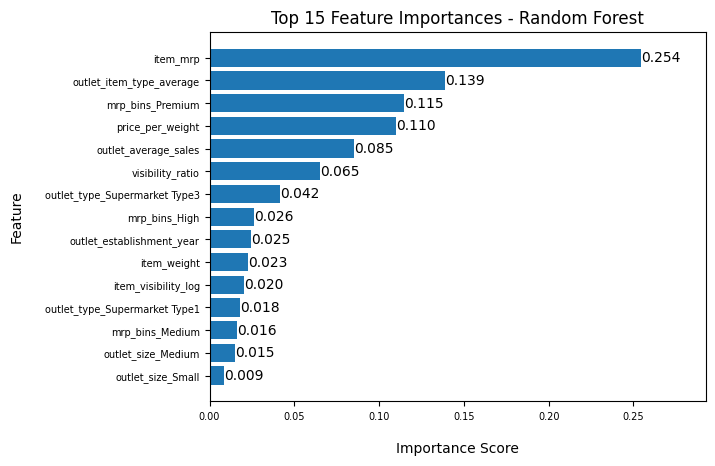

In [837]:
feature_imp = random_forest_optimized.best_estimator_.feature_importances_

features_imp = pd.DataFrame({"feature": X_train.columns, "importance": importances}).sort_values("importance", ascending=False)

top_features = importance_df.head(15)

ax = plt.barh(top_features["feature"], top_features["importance"])
plt.gca().invert_yaxis()
plt.tick_params(labelsize = 7)
plt.xlim(0, top_features["importance"].max() * 1.15)
plt.xlabel("Importance Score", labelpad = 15)
plt.ylabel("Feature", labelpad = 15)
plt.title("Top 15 Feature Importances - Random Forest")

for bar in ax:
    width = bar.get_width()
    plt.text(width, bar.get_y() + bar.get_height()/2,
             f"{width:.3f}",
             va="center")

plt.show()

To better understand what drives the model’s predictions, feature importance from the optimized Random Forest model is examined.

Feature importance measures how much each feature contributes to reducing prediction error across the trees in the model. Higher importance values indicate that a feature plays a stronger role in predicting item outlet sales.

From the chart, item_mrp appears to be the most influential feature, suggesting that product price is a strong predictor of sales. Store-level characteristics such as outlet_item_type_average and outlet_average_sales are also highly important, indicating that historical outlet performance and product category behavior within an outlet influence sales outcomes.

Other engineered features such as price_per_weight, visibility_ratio, and the MRP price bins also contribute to the model’s predictions. This highlights the value of the feature engineering steps performed earlier, as several of the created features appear among the most important predictors.